# GAIPO: Graph Artificial Intelligence for Pediatric Oncology

The Childhood Cancer Data Initiative (CCDI) ecosystem provides essential clinicogenomic data for deep learning in pediatric cancer research. To enable the efficient use of the CCDI resource for AI model training and implementation, we developed a generic graph AI platform, Graph Artificial Intelligence for Pediatric Oncology (GAIPO), as well as the standards of data, model, and pipeline, to streamline the use of CCDI clinicogenomics data of various data modalities from bulk and single-cell omics data to clinical information in AI development. GAIPO provides a comprehensive workflow: 
- (1) **Data fetching** through CCDI Data Federation Resource API and cBioPortal API for clinical metadata, multi-omics, and spatial transcriptomics data; 
- (2) **Data modeling** through mapping and harmonizing the fetched clinical and genomics data according to the CCDI data model; 
- (3) **Graph construction** functionalities through GraphML from NetworkX; 
- (4) **Graph AI** implementation of existing models; 
- (5) **Post-analysis** (feature importance and survival analysis).

## Content
The table of contents of GAIPO is shown below: <br>
GAIPO/ <br>
├── Dockerfile <br>
├── docker-compose.yaml <br>
├── requirements.txt <br>
├── config/ <br>
│   └── pipeline_config.yaml <br>
├── src/ <br>
│   ├── gdcdictionary/schemas/ <br>
│   ├── data_source.py        # Fetch subject & sample IDs from CCDI Data Federation API <br>
│   ├── extractor.py          # Fetch processed clinical & bulk genomics data from cBioPortal API <br>
│   ├── data_model.py <br>
│   ├── processor.py <br>
│   ├── graph_constructor.py <br>
│   ├── graph_ai_model.py <br>
│   └── post_analysis.py <br>
├── data/ <br>
│   ├── fetch/ <br>
│   │   ├── ccdi_api_request/ <br>
│   │   │   ├── sample_ids/{cancer_type | study_id}.csv <br>
│   │   │   └── subject_ids/{cancer_type | study_id}.csv <br>
│   │   └── cbioportal_api_request/ <br>
│   │       └── {cancer_type | study_id}/ <br>
│   │           ├── clinical.csv <br>
│   │           └── expression.tsv <br>
│   └── gdm/                   # GAIPO Data Model (GDM) <br>
│       ├── clinical/ <br>
│       │   ├── clinical_subjects.parquet <br>
│       │   └── clinical_samples.parquet <br>
│       └── features/ <br>
│           ├── mrna.zarr (+ row/col index Parquets) <br>
│           ├── mirna.zarr (+ row/col index Parquets) <br>
│           └── methylation.zarr (+ row/col index Parquets) <br>

This tutorial mainly focus on two parts:
- (1) Introduction of the elements of GAIPO platform
- (2) Code demo for using GAIPO| GAIPO/


## Instruction 
### 0. Get study ids for pediratric cancers
From cBioPortal, 
From PedcBioPortal, you need to obtain an API token from your profile page on PedcBioPortal and set it as an environment variable. On the PedcBioPortal page, you can click "logged in as <your_username>" and choose "Data Access Toke", then you can click "Download Token" button for the Web API of PedcBioPortal.


In [ ]:
# Fetch study ids for Glioma and Wilms Tumor via cBioPortal API
import requests

BASE = "https://www.cbioportal.org/api"
headers = {"accept": "application/json"}

resp = requests.get(f"{BASE}/studies", headers=headers)
resp.raise_for_status()
studies = resp.json()

def match_keywords(s, keywords):
    # case-insensitive match in name, description, cancerType etc
    txt = (s.get("name","") + " " + s.get("description","") + " " + s.get("cancerType", "")).lower()
    return any(kw.lower() in txt for kw in keywords)

glioma_keywords = ["high-grade glioma", "low-grade glioma"]
wilms_keywords = ["wilms", "nephroblastoma"]

glioma_studies = [s for s in studies if match_keywords(s, glioma_keywords)]
wilms_studies = [s for s in studies if match_keywords(s, wilms_keywords)]

print("Glioma candidates:", [(s["studyId"], s["name"]) for s in glioma_studies])
print("Wilms candidates:", [(s["studyId"], s["name"]) for s in wilms_studies])

Glioma candidates: [('difg_msk_2023', 'IDH-mutated Diffuse Glioma (MSK, Clin Cancer Res 2024)'), ('brain_cptac_2020', 'Pediatric Brain Cancer (CPTAC/CHOP, Cell 2020)'), ('lgg_ucsf_2014', 'Low-Grade Gliomas (UCSF, Science 2014)')]
Wilms candidates: [('wt_target_2018_pub', "Pediatric Wilms' Tumor (TARGET, 2018)"), ('wt_target_gdc', "Wilms' Tumor (TARGET GDC, 2025)")]


In [26]:
# Fetch study ids for PBTA (Pediatric Brain Tumor Atlas) via PedcBioPortal API
from bravado.client import SwaggerClient
from bravado.requests_client import RequestsClient

BASE = "https://pedcbioportal.kidsfirstdrc.org"
SWAGGER_URL = f"{BASE}/api/v2/api-docs"

TOKEN = "eyJhbGciOiJIUzI1NiIsInR5cCIgOiAiSldUIiwia2lkIiA6ICI4YWNlNDU1OS03ZDFlLTQ3YzAtOWE0ZC1mYWJiYTY4ODRmMzYifQ.eyJpYXQiOjE3NjA0OTUyOTIsImp0aSI6IjYxZWU4MmI4LWMzMjYtNDc1MS04NzBlLTYxZmVhNGU3ZDQ5MSIsImlzcyI6Imh0dHBzOi8va2V5Y2xvYWsua2lkc2ZpcnN0ZHJjLm9yZy9yZWFsbXMvcGVkY2Jpb3BvcnRhbCIsImF1ZCI6Imh0dHBzOi8va2V5Y2xvYWsua2lkc2ZpcnN0ZHJjLm9yZy9yZWFsbXMvcGVkY2Jpb3BvcnRhbCIsInN1YiI6IjEyMjAyODU2LTk0ODMtNDA2ZS04YzJkLTI3ODJkNTU0YWUyMiIsInR5cCI6Ik9mZmxpbmUiLCJhenAiOiJwZWRjYmlvcG9ydGFsLWFwaSIsInNlc3Npb25fc3RhdGUiOiI5ZGM0MTc0ZS0xZTgyLTRlZTEtYjZkOC1lMTVmYjAxMDg0OTkiLCJzY29wZSI6Im9wZW5pZCBvZmZsaW5lX2FjY2VzcyBwcm9maWxlIGVtYWlsIiwic2lkIjoiOWRjNDE3NGUtMWU4Mi00ZWUxLWI2ZDgtZTE1ZmIwMTA4NDk5In0.OBPmQasHaQy7n65qCPtUY_Ny4PmWqq9oiLSvGIK9Nuk"  # get this from your PedcBioPortal/cBioPortal account
# TOKEN = os.getenv("PEDCBIO_TOKEN")  # user sets this in their environment
if not TOKEN:
    raise SystemExit("Please set PEDCBIO_TOKEN to your API token")

http_client = RequestsClient()
http_client.session.headers.update({
    "Authorization": f"Bearer {TOKEN}",
    "Accept": "application/json"
})

client = SwaggerClient.from_url(
    SWAGGER_URL,
    http_client=http_client,
    config={
        "validate_requests": False,
        "validate_responses": False,
        "validate_swagger_spec": False
    }
)

# fetch all studies
studies = client.Studies.getAllStudiesUsingGET().result()

# find PBTA (Pediatric Brain Tumor Atlas)
pbta = [s for s in studies if "pbta" in s.studyId.lower() or "pbta" in (s.name or "").lower()]
print([(s.studyId, s.name) for s in pbta])

[('cptac_cbttc', 'Proteomics (CBTTC, PBTA, Provisional)'), ('openpbta', 'Open Pediatric Brain Tumor Atlas (OpenPBTA)'), ('open_chordoma', 'Open Chordoma (Chordoma Foundation, PBTA, dbGap, GEO, Provisional)'), ('pbta_all', 'Pediatric Brain Tumor Atlas (PBTA, Provisional)')]


In [25]:
wt = [s for s in studies if ("wilms" or "Nephroblastoma") in s.studyId.lower() or ("wilms" or "Nephroblastoma") in (s.name or "").lower()]
print([(s.studyId, s.name) for s in wt])

[]



### 1. CCDI Federation subjects & samples IDs by cancer-type terms
We are first going to fetch sample and subject/patient IDs from the CCDI Data Federation, and write subject_ids / sample_ids in to data.

The config/
1) Builds active cancer-type vocabularies from config:
     - default_type_terms + custom_type_terms
     - restricts to cancer_type_interest
     - compiles word-boundary regex per active type
2) Pages CCDI Federation endpoints to harvest:
     - /subject-diagnosis → subject_id + diagnoses (per source)
     - /sample-diagnosis → sample_id + subject_id + diagnoses (per source)
3) Classifies entities to cancer types via compiled regexes.
4) Writes per-type CSVs and an id map parquet for downstream steps.

Key inputs (from config/pipeline_config.yaml)

Data:
  ccdi_sample_diagnosis: https://federation.ccdi.cancer.gov/api/v1/sample-diagnosis
  ccdi_subject_diagnosis: https://federation.ccdi.cancer.gov/api/v1/subject-diagnosis
cancer_type_interest: ["Wilms Tumor", ...]
default_type_terms: { "Wilms Tumor": ["wilms", "nephroblastoma", ...], ... }
custom_type_terms: {}  # optional additions/overrides
target_source: null | "PCDC" | "KidsFirst" | ...  # filter to a single federation source
per_page: 100
timeout: 60
retry_status: [429, 500, 502, 503, 504]
studyId:
  "Wilms Tumor": "wt_target_2018_pub"    # used to annotate idmap.parquet

Outputs (relative to repo root)
data/fetch/ccdi_api_request/
  subject_ids/<cancer_type>.csv   # columns: source,subject_id,diagnoses
  sample_ids/<cancer_type>.csv    # columns: source,sample_id,subject_id,diagnoses
data/gdm/indexes/
  idmap.parquet                   # columns: source,sample_id,subject_id,diagnoses,study_id,
                                  #          node_id_subject,node_id_sample

Environment:
CONFIG_PATH      : path to pipeline_config.yaml (default: config/pipeline_config.yaml)
VERBOSE (yaml)   : verbose logs when True

Notes & tips:
- Classification is regex-based on the 'associated_diagnoses' values returned by the API.
- Set `target_source` in config to restrict to one federation backend (e.g., "PCDC") if you want a clean cohort.
- The helper writes/updates idmap.parquet idempotently and de-dups by sample_id.
- Rate limiting: on 429/5xx, the client backs off with simple 2**i sleeps up to 5 tries.

### 2. Data Modeling
GAIPO provides data infrastructure and standards that streamline the CCDI data utilization across diverse omics and clinical modalities, and helps users to implement CCDI data and other Genomic Data Commons (GDC)-compatible data for AI model development. Specifically, GAIPO maps cBioPortal clinical and genomics data and feature to a GDC-aligned data model, and provideS fast DuckDB access. <br>
#### Steps for GAIPO data modeling:
1. Loads GDC dictionary schemas (YAML) from a local checkout, normalizes refs/anchors,
   and builds validators (strict or lite).
2. Projects cBio clinical CSVs to GDC-like node tables:
   - case (submitter_id, project_id, disease_type, primary_site⋯)
   - sample (submitter_id, preservation_method, specimen_type, tissue_type, tumor_descriptor⋯)
   - demographic (submitter_id, sex_at_birth, vital_status, ethnicity, race)
   - diagnosis (case_submitter_id, tumor_stage⋯)
   - clinical () 
   - convenience link tables: links_sample_case, links_demographic_case
   - idmap (subject_id <-> sample_id) for graph joins
3. Registers feature stores (mrna/mirna/methylation.zarr) in a minimal 'file' node when present.
4. Creates TEMP VIEWs in DuckDB over the Parquets for instant cohorting/joins.

#### Inputs

- Clinical CSVs written by extractor:
    data/fetch/cbioportal_api_request/<Cancer_Type>/
      clinical_patients.csv, clinical_samples.csv
- Feature stores / indexes (optional; from extractor):
    data/gdm/features/*.zarr
    data/gdm/indexes/*_{rows,cols}.parquet
- Config: config/gdc_mapping.yaml
    project_id: WILMS_TUMOR_CBIO      # stamped on 'case' and 'file'
    schemas_dir: src/gdcdictionary/schemas
    gdm_root: data/gdm
    gdc_mapping:
      disease_type_map, primary_site_map, icdo_topography_map, icdo_morph_to_site_map, oncotree_to_site
      sample_suffix_map, preservation_map, preservation_default

#### Outputs (under gdm_root)
clinical/
  clinical_subjects.parquet
  clinical_samples.parquet
nodes/
  case.parquet
  sample.parquet
  demographic.parquet
  diagnosis.parquet           # optional but written if derivable
  nodes.parquet               # convenience catalog of node ids
indexes/
  idmap.parquet
  links_sample_case.parquet
  links_demographic_case.parquet
files/
  file.parquet                # minimal 'file' node rows for features
  file_full.parquet           # richer analytics view with sizes/md5
features/
  mrna.zarr, mirna.zarr, methylation.zarr  # (if present; not created here)

#### DuckDB TEMP VIEWs (non-reserved names)
subjects -> clinical/clinical_subjects.parquet
samples -> clinical/clinical_samples.parquet
gdc_case -> nodes/case.parquet
gdc_demographic -> nodes/demographic.parquet
gdc_diagnosis -> nodes/diagnosis.parquet
links_sample_case -> indexes/links_sample_case.parquet
links_demographic_case -> indexes/links_demographic_case.parquet
idmap, nodes, files, and feature index views if present

#### Validation modes

- Lite (default): relax required, allow additionalProperties. Great for iterative pipelines.
- Strict: set --strict or DM_GDC_STRICT=1 to enforce dictionary requirements.
  You may need to expand your mappings (e.g., preservation enums) to pass strict.

#### Environment

DM_CONFIG           : alternative config path (else CONFIG_PATH or default config/gdc_mapping.yaml)
CONFIG_PATH         : pipeline config (project_id, mappings, …)
DM_GDC_STRICT       : 1/0 to force strict/lite (CLI --strict overrides)
DM_DUCKDB_MODE      : memory | ro | rw   (default: memory)
DM_DUCKDB_PATH      : file path for persistent DB when mode=rw
DM_DUCKDB_RETRIES   : int retries on lock when mode=rw (default 0)
DM_DUCKDB_RETRY_SLEEP : seconds between retries (default 0.5)


#### Notes & tips

- We avoid the reserved word "case" for view names (use gdc_case).
- When writing the 'file' node for features, we compute md5 and byte sizes; state defaults to "validated".
- Schema normalization injects common anchors (uuid/state/project_id) and strips external refs so the validator
  works offline from your local YAML checkout.

In [78]:
import yaml
import graphviz

def plot_model_with_custom_labels(file_path, width=12, height=8):
    """
    Parses a YAML file and creates a graph, using custom edge labels
    when provided in the YAML.
    """
    with open(file_path, 'r') as f:
        data = yaml.safe_load(f)

    dot = graphviz.Digraph('DataModel', comment='Hierarchical Data Flow with Custom Labels')
    dot.attr(size=f'{width},{height}!')
    dot.attr(rankdir='TB', splines='ortho', nodesep='1.0')
    dot.attr('node', shape='plain')
    dot.attr('edge', fontsize='18', labeldistance='4.0', labelfontcolor='gray40')

    # Add nodes (this part is unchanged)
    nodes = data.get('Nodes', {})
    for node_name, node_details in nodes.items():
        label = '<<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="4">'
        label += f'<TR><TD BGCOLOR="#a9d0f5"><B>{node_name}</B></TD></TR>'
        props_list = node_details.get('Props', [])
        if props_list:
            for prop in props_list:
                label += f'<TR><TD ALIGN="LEFT">- {prop}</TD></TR>'
        label += '</TABLE>>'
        dot.node(node_name, label)

    # Add edges, checking for custom labels
    relationships = data.get('Relationships', {})
    for rel_name, rel_details in relationships.items():
        ends = rel_details.get('Ends', [])
        for link in ends:
            src_node = link.get('Src')
            dst_node = link.get('Dst')
            if src_node in nodes and dst_node in nodes:
                # --- KEY CHANGE HERE ---
                # Check for a specific 'Label' field in the link.
                # If it doesn't exist, fall back to the main relationship name (rel_name).
                label_to_use = link.get('Label', rel_name)
                
                dot.edge(src_node, dst_node, taillabel=label_to_use)

    return dot

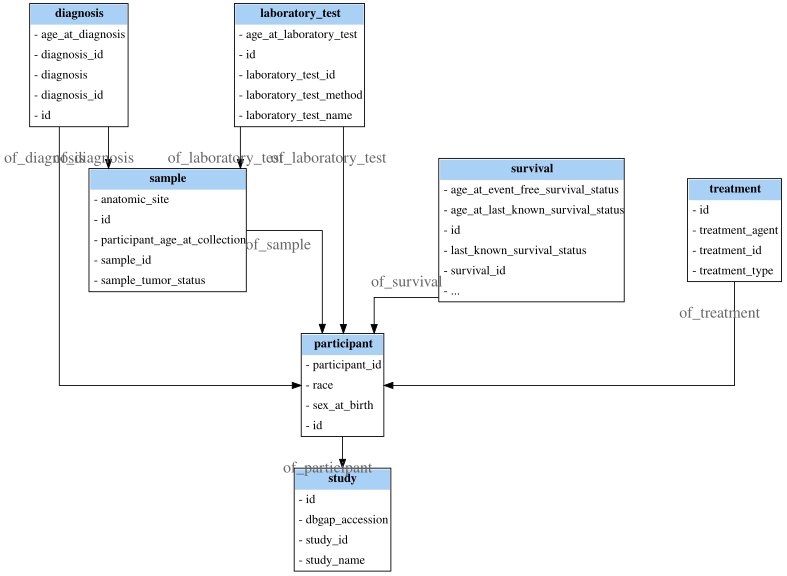

In [71]:
yaml_content = """
Handle: C3DC
Version: v4.0.5
Nodes:
  diagnosis: {Desc: '...', Tags: {...}, Props: [age_at_diagnosis, diagnosis_id, diagnosis, diagnosis_id, id]}
  participant: {Desc: '...', Tags: {...}, Props: [participant_id, race, sex_at_birth, id]}
  sample: {Desc: '...', Tags: {...}, Props: [anatomic_site, id, participant_age_at_collection, sample_id, sample_tumor_status]}
  study: {Desc: '...', Tags: {...}, Props: [id, dbgap_accession, study_id, study_name]}
  survival: {Desc: '...', Tags: {...}, Props: [age_at_event_free_survival_status, age_at_last_known_survival_status, id, last_known_survival_status, survival_id, ...]}
  laboratory_test: {Desc: '...', Tags: {...}, Props: [age_at_laboratory_test, id, laboratory_test_id, laboratory_test_method, laboratory_test_name]}
  treatment: {Desc: '...', Tags: {...}, Props: [id, treatment_agent, treatment_id, treatment_type]}
Relationships:
  of_diagnosis: {Props: null, Mul: many_to_one, Ends: [{Src: diagnosis, Dst: participant}, {Src: diagnosis, Dst: sample}]}
  of_laboratory_test: {Props: null, Mul: many_to_one, Ends: [{Src: laboratory_test, Dst: participant}, {Src: laboratory_test, Dst: sample}]}
  of_participant: {Props: null, Mul: many_to_one, Ends: [{Src: participant, Dst: study}]}
  of_sample: {Props: null, Mul: many_to_one, Ends: [{Src: sample, Dst: participant}]}
  of_survival: {Props: null, Mul: many_to_one, Ends: [{Src: survival, Dst: participant}]}
  of_treatment: {Props: null, Mul: many_to_one, Ends: [{Src: treatment, Dst: participant}]}
"""

with open('c3dc_model.yml', 'w') as f:
    f.write(yaml_content) # Replace with your full YAML string from the first prompt

# Generate the graph by calling the new function
data_model_graph_with_props = plot_model_with_custom_labels('c3dc_model.yml')
# Display the graph
data_model_graph_with_props

In [11]:
import os
import yaml
import graphviz
from IPython.display import Image, display

def plot_and_save_model(file_path, width=12, height=8, output_filename=None):
    """
    Parses a YAML file, creates a graph, and optionally saves it as a PNG file.
    
    Args:
        file_path (str): The path to the .yml model file.
        width (int): The desired width of the output image in inches.
        height (int): The desired height of the output image in inches.
        output_filename (str, optional): The base name for the output PNG file. 
                                         If None, no file is saved. Defaults to None.
    
    Returns:
        graphviz.Digraph: A Graphviz object ready to be displayed.
    """
    with open(file_path, 'r') as f:
        data = yaml.safe_load(f)

    dot = graphviz.Digraph('DataModel', comment='Hierarchical Data Flow')
    
    # Graph attributes
    dot.attr(size=f'{width},{height}!')
    dot.attr(rankdir='LR', splines='ortho', nodesep='1.0', dpi='300')
    dot.attr('node', fontsize='28', shape='plain')
    dot.attr('edge', fontsize='14', labeldistance='2.0', labelfontcolor='gray40')

    # Add nodes (unchanged)
    nodes = data.get('Nodes', {})
    for node_name, node_details in nodes.items():
        label = '<<TABLE BORDER="1" CELLBORDER="0" CELLSPACING="0" CELLPADDING="4">'
        label += f'<TR><TD BGCOLOR="#a9d0f5"><B>{node_name}</B></TD></TR>'
        props_list = node_details.get('Props', [])
        if props_list:
            for prop in props_list:
                label += f'<TR><TD ALIGN="LEFT">- {prop}</TD></TR>'
        label += '</TABLE>>'
        dot.node(node_name, label)

    # Add edges (unchanged)
    relationships = data.get('Relationships', {})
    for rel_name, rel_details in relationships.items():
        ends = rel_details.get('Ends', [])
        for link in ends:
            src_node = link.get('Src')
            dst_node = link.get('Dst')
            if src_node in nodes and dst_node in nodes:
                label_to_use = link.get('Label', rel_name)
                dot.edge(src_node, dst_node, taillabel=label_to_use)

    # --- KEY CHANGE: RENDER AND SAVE THE FILE ---
    if output_filename:
        # The .render() method saves the file. It automatically adds the extension.
        # 'cleanup=True' removes the intermediate source file (.dot).
        dot.render(output_filename, format='png', cleanup=True)
        print(f"Graph saved to '{os.path.abspath(output_filename)}.png'")

    return dot

# Generate the graph by calling the function
GAIPO_data_model_graph = plot_and_save_model('GAIPO_model.yml', width=12, height=8)

In [8]:
import pydot
import json
graph = pydot.Dot(graph_type="digraph", rankdir="TB")

for node in data["nodes"]:
    graph.add_node(pydot.Node(node["name"], shape="box", style="filled", fillcolor="lightyellow"))

for node in data["nodes"]:
    for link in node.get("links", []):
        if link["target_type"]:
            graph.add_edge(pydot.Edge(node["name"], link["target_type"], label=link["label"]))

graph.write_png("hierarchy.png")

### 3. Graph construction

GAIPO provides graph builders for multi-omics pipelines. Its scope currently implements **patient-similarity graphs for bulk omics** (MOGONET-style).
It also defines **empty placeholders** for **spatial single-cell** graph construction; 

#### 3.1 Bulk omics (patient-similarity)

Goal
  Build adjacency matrices over patients using cosine similarity on preprocessed,
  per-modality feature matrices (rows = patients, cols = features). This follows
  the spirit of MOGONET:
    • Fit selectors/scalers upstream on TRAIN only (done in processor.py)
    • TRAIN graph: edges selected by an adaptive “radius” so each node has about
      `edges_per_node` neighbors (cosine distance thresholding)
    • TRTE block graph: build cross edges (TRAIN↔TEST) using the TRAIN threshold,
      with no TEST↔TEST edges
    • Weights = cosine similarity (1 − cosine distance)
    • Symmetrize with max(A, Aᵀ), add self-loops, then row-normalize

Inputs (produced by processor.py)
  data/gdm/filtered/<Cancer_Type>/<mod>_train.parquet
  data/gdm/filtered/<Cancer_Type>/<mod>_test.parquet
  where <mod> ∈ {mrna, mirna, methylation}

Outputs
  data/gdm/graphs/<Cancer_Type>/<mod>_train.adj.npz         # CSR adjacency for TRAIN
  data/gdm/graphs/<Cancer_Type>/<mod>_trte_block.adj.npz    # CSR adjacency for TRAIN|TEST block
  (optional) .graphml exports for inspection

Config (config/pipeline_config.yaml)
  graph:
    edges_per_node: 15     # neighbor budget used to derive the cosine distance cutoff on TRAIN
    save_graphml: false    # write GraphML alongside .npz if true

  cancer_type_interest: ["Wilms Tumor", ...]
  expression_profiles:
    "Wilms Tumor": [mrna, mirna, methylation]

Pipeline entrypoint (config-driven)
  graph_construct()
    • Loops over configured cancer types and modalities
    • Loads *_train.parquet and *_test.parquet
    • Computes TRAIN threshold; writes <mod>_train.adj.npz and <mod>_trte_block.adj.npz
    • Optional GraphML if graph.save_graphml=true

CLI utilities (ad-hoc)
  python src/graph_constructor.py bulk-train \
    --matrix data/gdm/filtered/mrna_train.parquet \
    --format parquet \
    --edges-per-node 5 \
    --out data/gdm/graphs/mrna_train.adj.npz \
    --out-graphml data/gdm/graphs/mrna_train.graphml

  python src/graph_constructor.py bulk-split \
    --matrix-train data/gdm/filtered/mrna_train.parquet \
    --matrix-test  data/gdm/filtered/mrna_test.parquet \
    --format parquet \
    --edges-per-node 5 \
    --out-train data/gdm/graphs/mrna_train.adj.npz \
    --out-trte  data/gdm/graphs/mrna_trte_block.adj.npz

Run via main.py
  python -m src.main --call graph_construct
 or chained:
  python -m src.main --call data_fetch,data_extract,process,graph_construct

Notes
  • Modality synonyms are normalized (e.g., “microrna” → “mirna”).
  • If a modality’s train/test parquet is missing, that modality is skipped for that cancer type.
  • Adjacencies are standard SciPy CSR saved with scipy.sparse.save_npz; they can be read in
    PyTorch Geometric after converting to edge_index (helper provided).

Key functions (bulk)
  compute_adaptive_radius_parameter_mogonet(X_tr, params)
  build_train_adjacency_mogonet(X_tr, radius=None, params)
  build_trte_block_adjacency_mogonet(X_tr, X_te, radius, params)
  graph_construct()   # config-driven pipeline step

Helpers
  csr_to_edge_index(A)              # -> (edge_index, weights) numpy arrays
  csr_to_torch_coo(A, device=None)  # -> torch.sparse_coo_tensor
  csr_to_networkx(A, node_ids=None) # -> networkx Graph
  save_adjacency_npz(A, out_path)
  save_graph_graphml(G, out_path)
  
#### 3.2 Spatial single-cell graphs (placeholders) 

### 4. Graph AI implementation
GAIPO currently provides MOGONET-style GNN adapted to this project's I/O

Supports two modes:
1) Pretrained inference: load saved weights, build cross (train|valid) block adjacencies using
   TRAIN-derived radius, run inference on user-provided validation data, and compute feature
   importance by ablation (optional).
2) Train/evaluate: given train/test splits, per-modality features (samples x features), and
   prebuilt adjacencies (or feature matrices to build them on-the-fly via graph_constructor),
   train the GCN encoders + per-view classifiers (+ VCDN fusion) and report metrics.

This module expects you to have used processor.py and graph_constructor.py beforehand:
- processor.py supplies X_tr_dict, X_te_dict, y_tr, y_te, tr_ids, te_ids
- graph_constructor.py supplies adjacency builders respecting MOGONET logic


## Code demo
The GAIPO project is developped using Python. All the functions are stored in Python files under "/src/" folder and also need configure supports from the "/config/" folder.CLI / Pipeline
Code are stored in src/data_source.py. Recommended: via main driver. Try to run below interminal:
- python -m src.main --call data_fetch

Ad-hoc (module has a __main__ that calls data_fetch()):
- python -m src.data_source

Here shows the detailed 

- CLI / Pipeline

    - Recommended (pipeline):
    python -m src.main --call data_model
  (Runs `build_data_model()` for all cancer types listed in config and then attaches views.)

    - Ad-hoc demo:
    python -m src.data_model \
      --schemas-dir src/gdcdictionary/schemas \
      --gdm-root data/gdm \
      --cbio-dir data/fetch/cbioportal_api_request/Wilms_Tumor \
      --project-id WILMS_TUMOR_CBIO

- Ad-hoc SQL (via pipeline data_query)
Join case + diagnosis + demographic via link table; get a cohort’s sample_ids
PIPELINE_SQL=$'WITH cohort AS (
  SELECT c.submitter_id AS subject_id
  FROM gdc_case c
  LEFT JOIN gdc_diagnosis d
    ON d.case_submitter_id = c.submitter_id
  LEFT JOIN links_demographic_case ldc
    ON ldc.case_submitter_id = c.submitter_id
  LEFT JOIN gdc_demographic demo
    ON demo.submitter_id = ldc.demographic_submitter_id
  WHERE upper(coalesce(d.tumor_stage, '''')) LIKE ''III%''
    AND lower(coalesce(demo.sex_at_birth, '''')) = ''female''
)
SELECT DISTINCT i.sample_id
FROM cohort c
JOIN idmap i USING (subject_id)
ORDER BY 1' \
python -m src.main --call data_query